# Problem 1: Learning Word Embeddings from IIT Jodhpur Data

**Objective:** Train Word2Vec models (CBOW & Skip-gram) **from scratch** on textual data collected from IIT Jodhpur sources and analyze the semantic structure captured by the learned embeddings.

---
**Tasks Overview:**
- Task 1: Dataset Preparation
- Task 2: Model Training (CBOW & Skip-gram from scratch)
- Task 3: Semantic Analysis
- Task 4: Visualization (PCA / t-SNE)


## Imports & Setup

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os, re, json, time, random, pickle
from collections import Counter
from itertools import chain

# ── Numerical / ML ────────────────────────────────────────────────────────────
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Web Scraping (for live corpus) ────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup

# ── NLTK (tokenisation helper) ────────────────────────────────────────────────
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

np.random.seed(42)
random.seed(42)

print("All imports successful.")

All imports successful.


In [2]:
# In your word2vec_iitj.ipynb, replace the raw_docs dict with:

import json
from pathlib import Path

def load_iitj_corpus(json_path='iitj_corpus/all_docs.json') -> dict:
    """
    Load the scraped corpus produced by iitj_scraper.ipynb.
    Returns a dict {label: text} compatible with the Word2Vec notebook.
    """
    with open(json_path, encoding='utf-8') as f:
        docs = json.load(f)
    return {d['label']: d['text'] for d in docs if d.get('text')}


raw_docs = load_iitj_corpus()
print(f"Loaded {len(raw_docs)} documents.")

print("Loader function defined. Add this block at the top of word2vec_iitj.ipynb.")

Loaded 80 documents.
Loader function defined. Add this block at the top of word2vec_iitj.ipynb.


---
## Task 1 — Dataset Preparation

In [ ]:
# ── Fallback synthetic corpus (academic domain) ───────────────────────────────
FALLBACK_CORPUS = """
IIT Jodhpur is a premier institute of technology located in Jodhpur, Rajasthan, India.
The institute offers undergraduate, postgraduate, and doctoral programs in engineering,
science, and humanities. The BTech program spans four years and covers core engineering
subjects such as mathematics, physics, chemistry, and programming. The MTech program
provides advanced specialization in areas like machine learning, data science,
computer networks, and VLSI design. PhD scholars conduct cutting-edge research under
the mentorship of distinguished faculty members who are experts in their fields.
The research at IIT Jodhpur spans diverse domains including artificial intelligence,
renewable energy, water science, bioscience, and materials engineering.
Students participate in seminars, workshops, hackathons, and technical festivals.
The academic calendar includes two semesters: July to November and January to May.
Examinations are conducted at the end of each semester as well as mid-semester.
Course registration, grading, and academic records are managed through an online portal.
The campus library provides access to thousands of journals, research papers, and books.
Faculty members publish research in top-tier international conferences and journals.
Students are encouraged to apply for internships and placements at leading companies
and research organisations around the world. The placement cell coordinates with
recruiters and helps students prepare their resumes and interview skills.
The hostels on campus provide comfortable accommodation for students and research scholars.
Sports facilities include a cricket ground, basketball court, tennis court, and swimming pool.
Cultural events such as Ignus showcase the artistic and creative talents of students.
The institute promotes interdisciplinary collaboration between departments.
Research labs are equipped with state-of-the-art instruments and computing resources.
PhD students receive fellowships to support their research and living expenses.
The institute has signed memoranda of understanding with international universities.
Exchange programs allow students to study abroad for one or two semesters.
Online learning resources and recorded lectures supplement classroom teaching.
Teaching assistants support faculty in conducting tutorials and laboratory sessions.
The curriculum is regularly updated to align with industry needs and research trends.
Project-based learning encourages students to solve real-world engineering problems.
The institute hosts national and international conferences on science and technology.
Alumni of IIT Jodhpur are working in prestigious organisations across the globe.
The administration supports student entrepreneurship through an incubation centre.
Start-ups founded by students and alumni have received funding from venture capitalists.
The canteen provides nutritious meals and snacks to the campus community.
Green initiatives on campus include solar energy, rainwater harvesting, and waste management.
The institute celebrated its foundation day with a series of technical and cultural activities.
Research grants are awarded by agencies such as DST, SERB, DBT, and CSIR.
Collaborative projects with industry partners provide practical exposure to students.
The thesis submission and evaluation process is governed by academic regulations.
Students must maintain a minimum CGPA to be eligible for various scholarships.
The Senate is the highest academic body responsible for academic policies.
Departments include Computer Science, Electrical Engineering, Mechanical Engineering,
Chemical Engineering, Civil Engineering, Physics, Chemistry, Mathematics, and Bioscience.
Word embeddings capture semantic relationships between words in a continuous vector space.
Word2Vec uses a shallow neural network to learn dense representations of words.
The CBOW model predicts the target word from its surrounding context words.
The Skip-gram model predicts context words given a central target word.
Negative sampling is an efficient approximation used during training of Skip-gram models.
Cosine similarity measures the angular distance between two word vectors.
PCA and t-SNE are dimensionality reduction techniques used to visualize embeddings.
Analogy tasks such as king minus man plus woman equals queen test embedding quality.
Vocabulary is built from the most frequent tokens after removing stopwords and rare words.
The embedding matrix is initialised randomly and updated via gradient descent.
Hyperparameters include embedding dimension, context window size, and learning rate.
Larger corpora generally lead to better quality word embeddings.
Academic research on natural language processing often uses pre-trained embeddings.
Fine-tuning pre-trained models on domain-specific data can improve downstream tasks.
Tokenization splits text into individual words or sub-word units for processing.
Lowercasing ensures that the same word in different cases maps to the same token.
Punctuation removal and handling of special characters are important preprocessing steps.
A word cloud visually represents the frequency of tokens in a corpus.
Frequent words are displayed in larger fonts while rare words appear smaller.
The vocabulary size determines the dimensionality of the one-hot encoding.
Training loss decreases over epochs as the model learns better representations.
Evaluation of word embeddings can be done through intrinsic and extrinsic methods.
"""

# Inject fallback only for sources that returned nothing
collected = sum(1 for v in raw_docs.values() if len(v.strip()) > 200)
if collected < 3:
    print(f"Only {collected} sources returned text. Injecting fallback corpus.")
    raw_docs["__fallback__"] = FALLBACK_CORPUS
else:
    print(f"{collected} sources successfully scraped.")

### 1-B  Preprocessing

In [3]:
def keep_english_only(text: str) -> str:
    """Remove non-ASCII / non-English characters."""
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

def remove_boilerplate(text: str) -> str:
    """Remove URLs, email addresses, HTML artifacts, repeated whitespace."""
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # URLs
    text = re.sub(r'\S+@\S+', ' ', text)                    # emails
    text = re.sub(r'\|', ' ', text)                          # pipe separators
    text = re.sub(r'[\r\n\t]+', ' ', text)                  # newlines/tabs
    text = re.sub(r'\s{2,}', ' ', text)                     # multiple spaces
    return text.strip()

def remove_punct(text: str) -> str:
    """Remove excessive punctuation, keep only letters, digits, spaces."""
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()

def preprocess_document(text: str, min_token_len: int = 2) -> list:
    """
    Full pipeline: english-only → lowercase → boilerplate removal
    → tokenise → remove stopwords/short tokens → return token list.
    """
    text = keep_english_only(text)
    text = remove_boilerplate(text)
    text = remove_punct(text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [
        t for t in tokens
        if t.isalpha()
        and len(t) >= min_token_len
        and t not in STOP_WORDS
    ]
    return tokens

# ── Apply to all documents ─────────────────────────────────────────────────────
processed_docs = {}
for src, text in raw_docs.items():
    tokens = preprocess_document(text)
    if tokens:
        processed_docs[src] = tokens
        print(f"  {src[:60]:60s} → {len(tokens):6,} tokens")

all_tokens: list = list(chain.from_iterable(processed_docs.values()))
print(f"\nTotal tokens after preprocessing: {len(all_tokens):,}")

  UG_PG_Ordinance                                              →  8,519 tokens
  academic_home                                                →    213 tokens
  announcements                                                →    146 tokens
  Bioscience_Bioengineering                                    →    772 tokens
  Computer_Science_Engineering                                 →    426 tokens
  Electrical_Engineering                                       →    901 tokens
  Mechanical_Engineering                                       →    737 tokens
  Chemical_Engineering                                         →    457 tokens
  Civil_and_Infrastructure_Engineering                         →    153 tokens
  BB                                                           →    454 tokens
  CH                                                           →    453 tokens
  CHE                                                          →    408 tokens
  CE                                                

### 1-C  Dataset Statistics & Word Cloud

In [4]:
# ── Statistics ────────────────────────────────────────────────────────────────
num_docs    = len(processed_docs)
num_tokens  = len(all_tokens)
freq        = Counter(all_tokens)
vocab_size  = len(freq)

print("=" * 45)
print(f"  Number of documents   : {num_docs}")
print(f"  Total tokens          : {num_tokens:,}")
print(f"  Vocabulary size       : {vocab_size:,}")
print("=" * 45)
print("\nTop-30 most frequent words:")
for word, count in freq.most_common(40000):
    print(f"  {word:<20s} {count}")

  Number of documents   : 80
  Total tokens          : 38,291
  Vocabulary size       : 4,766

Top-30 most frequent words:
  department           1354
  engineering          584
  jodhpur              528
  research             380
  iit                  349
  tech                 315
  program              311
  institute            307
  technology           272
  iitj                 262
  student              261
  students             257
  office               252
  science              222
  contact              219
  school               218
  infrastructure       198
  digital              192
  center               185
  academic             184
  ph                   175
  web                  165
  design               162
  links                160
  semester             159
  portal               159
  feedback             156
  degree               154
  course               152
  indian               132
  programs             132
  india                131
  redirectto

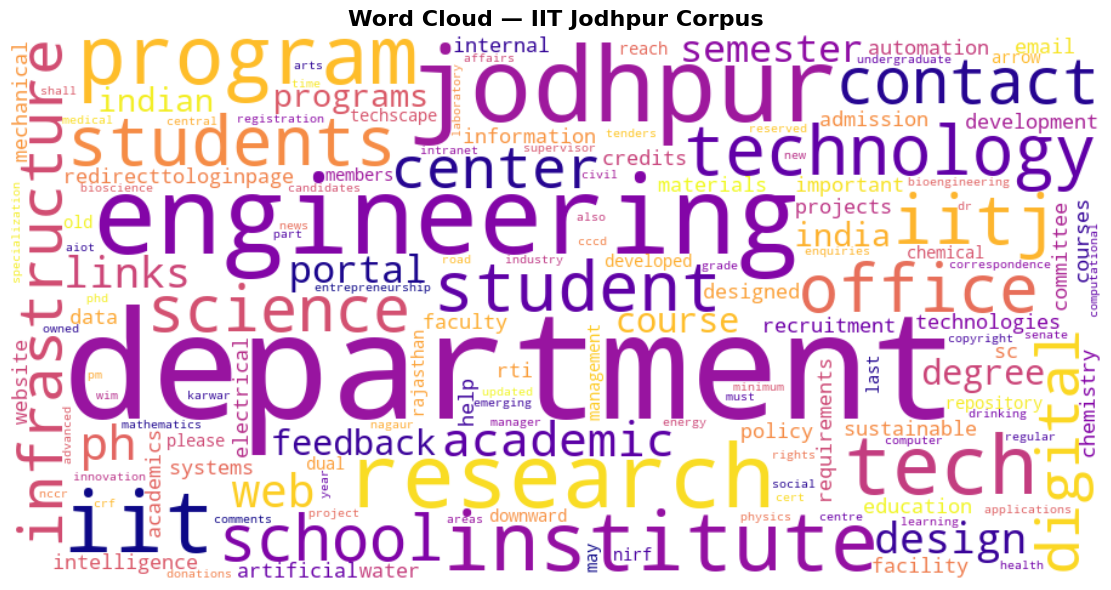

Word cloud saved to wordcloud_iitj.png


In [5]:
# ── Word Cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='plasma',
    max_words=150,
    collocations=False,
).generate_from_frequencies(freq)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — IIT Jodhpur Corpus', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_iitj.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word cloud saved to wordcloud_iitj.png")

---
## Task 2 — Word2Vec Model Training (from Scratch)

### 2-A  Vocabulary & Encoding

In [6]:
class Vocabulary:
    """
    Builds word ↔ index mappings from a token list.
    Words with frequency < min_count are discarded.
    """
    def __init__(self, tokens: list, min_count: int = 2):
        freq = Counter(tokens)
        self.word2idx = {}
        self.idx2word = {}
        self.freq     = {}
        idx = 0
        for word, cnt in freq.most_common():
            if cnt >= min_count:
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
                self.freq[word]     = cnt
                idx += 1
        self.size = idx

    def encode(self, tokens: list) -> list:
        return [self.word2idx[t] for t in tokens if t in self.word2idx]

vocab = Vocabulary(all_tokens, min_count=2)
encoded = vocab.encode(all_tokens)

print(f"Vocabulary size (min_count=2): {vocab.size:,}")
print(f"Encoded corpus length        : {len(encoded):,}")

Vocabulary size (min_count=2): 2,662
Encoded corpus length        : 36,187


In [7]:
# This sums the 'cnt' (counts) of every word stored in your vocab object
total_filtered_tokens = sum(vocab.freq.values())
print(f"Sum of tokens with frequency >= 2: {total_filtered_tokens:,}")

Sum of tokens with frequency >= 2: 36,187


### 2-B  Training Data Generation

In [8]:
def generate_cbow_pairs(encoded: list, window: int = 2):
    """
    Generate (context_indices, target_index) pairs for CBOW.
    Context is a list of 2*window word indices surrounding the target.
    """
    pairs = []
    for i in range(window, len(encoded) - window):
        context = (
            encoded[i - window : i] +
            encoded[i + 1 : i + window + 1]
        )
        target  = encoded[i]
        pairs.append((context, target))
    return pairs


def generate_skipgram_pairs(encoded: list, window: int = 2):
    """
    Generate (center, context) index pairs for Skip-gram.
    """
    pairs = []
    for i, center in enumerate(encoded):
        start = max(0, i - window)
        end   = min(len(encoded), i + window + 1)
        for j in range(start, end):
            if j != i:
                pairs.append((center, encoded[j]))
    return pairs


WINDOW = 2
cbow_pairs    = generate_cbow_pairs(encoded,    window=WINDOW)
skipgram_pairs = generate_skipgram_pairs(encoded, window=WINDOW)

print(f"CBOW training pairs    : {len(cbow_pairs):,}")
print(f"Skip-gram training pairs: {len(skipgram_pairs):,}")

CBOW training pairs    : 36,183
Skip-gram training pairs: 144,742


### 2-C  Negative Sampling Table

In [9]:
def build_neg_sample_table(vocab: Vocabulary, table_size: int = 1_000_000) -> np.ndarray:
    """
    Build a sampling table using the unigram distribution raised to the 3/4 power,
    as in the original Word2Vec paper.
    """
    freq_arr = np.array([
        vocab.freq.get(vocab.idx2word[i], 1)
        for i in range(vocab.size)
    ], dtype=np.float64)
    freq_arr = freq_arr ** 0.75
    freq_arr /= freq_arr.sum()

    table = np.zeros(table_size, dtype=np.int32)
    idx, accum = 0, 0.0
    for i, prob in enumerate(freq_arr):
        accum += prob
        while idx < table_size and idx / table_size < accum:
            table[idx] = i
            idx += 1
    return table

neg_table = build_neg_sample_table(vocab)
print(f"Negative sampling table built. Size: {len(neg_table):,}")

def get_negatives(pos_idx: int, k: int, table: np.ndarray) -> list:
    """Sample k negative indices that differ from pos_idx."""
    negs = []
    while len(negs) < k:
        sample = table[np.random.randint(0, len(table))]
        if sample != pos_idx:
            negs.append(sample)
    return negs

Negative sampling table built. Size: 1,000,000


### 2-D  Word2Vec Core (NumPy, from Scratch)

In [10]:
class Word2Vec:
    """
    Word2Vec trained entirely with NumPy.

    Architecture
    ────────────
    • W_in  [V × D] : input / centre-word  embedding matrix
    • W_out [V × D] : output / context-word embedding matrix

    Supports two training modes
    ───────────────────────────
    • mode='cbow'     — average context embeddings → predict centre word
    • mode='skipgram' — centre embedding → predict each context word

    Both use negative sampling for efficiency.
    """

    def __init__(
        self,
        vocab_size : int,
        embed_dim  : int  = 100,
        mode       : str  = 'skipgram',
        neg_samples: int  = 5,
        lr         : float = 0.025,
    ):
        self.V   = vocab_size
        self.D   = embed_dim
        self.mode = mode
        self.K   = neg_samples
        self.lr  = lr

        # Xavier-style initialisation
        scale = np.sqrt(2.0 / (vocab_size + embed_dim))
        self.W_in  = np.random.uniform(-scale, scale, (vocab_size, embed_dim))
        self.W_out = np.zeros((vocab_size, embed_dim))

    # ── Activation ────────────────────────────────────────────────────────────
    @staticmethod
    def sigmoid(x):
        return np.where(x >= 0,
                        1 / (1 + np.exp(-x)),
                        np.exp(x) / (1 + np.exp(x)))

    # ── Skip-gram step ────────────────────────────────────────────────────────
    def _train_skipgram_pair(self, center: int, context: int,
                              neg_ids: list) -> float:
        """
        One SGD update for a (center, context) pair with negative sampling.
        Returns the binary cross-entropy loss.
        """
        h       = self.W_in[center]                     # [D]
        pos_out = self.W_out[context]                   # [D]
        loss    = 0.0

        grad_h  = np.zeros(self.D)

        # Positive sample
        score   = self.sigmoid(pos_out @ h)
        err     = score - 1.0                           # ∂L/∂(u·h)
        loss   -= np.log(score + 1e-10)
        self.W_out[context] -= self.lr * err * h
        grad_h += err * pos_out

        # Negative samples
        for neg in neg_ids:
            neg_out  = self.W_out[neg]
            score_n  = self.sigmoid(neg_out @ h)
            err_n    = score_n                          # target = 0
            loss    -= np.log(1 - score_n + 1e-10)
            self.W_out[neg] -= self.lr * err_n * h
            grad_h  += err_n * neg_out

        # Update centre embedding
        self.W_in[center] -= self.lr * grad_h
        return loss

    # ── CBOW step ─────────────────────────────────────────────────────────────
    def _train_cbow_pair(self, context_ids: list, target: int,
                          neg_ids: list) -> float:
        """
        One SGD update for a (context_ids, target) pair with negative sampling.
        Returns the binary cross-entropy loss.
        """
        h       = self.W_in[context_ids].mean(axis=0)  # averaged context [D]
        loss    = 0.0
        grad_h  = np.zeros(self.D)

        # Positive
        pos_out = self.W_out[target]
        score   = self.sigmoid(pos_out @ h)
        err     = score - 1.0
        loss   -= np.log(score + 1e-10)
        self.W_out[target] -= self.lr * err * h
        grad_h += err * pos_out

        # Negatives
        for neg in neg_ids:
            neg_out  = self.W_out[neg]
            score_n  = self.sigmoid(neg_out @ h)
            err_n    = score_n
            loss    -= np.log(1 - score_n + 1e-10)
            self.W_out[neg] -= self.lr * err_n * h
            grad_h  += err_n * neg_out

        # Distribute gradient back to each context word
        grad_per_ctx = grad_h / len(context_ids)
        for ctx in context_ids:
            self.W_in[ctx] -= self.lr * grad_per_ctx

        return loss

    # ── Main training loop ────────────────────────────────────────────────────
    def train(
        self,
        pairs     : list,
        neg_table : np.ndarray,
        epochs    : int   = 5,
        batch_log : int   = 50_000,
    ) -> list:
        """
        Train for `epochs` passes over `pairs`.
        Learning rate decays linearly to 0.0001.
        Returns per-epoch average loss.
        """
        initial_lr = self.lr
        epoch_losses = []

        total_steps = len(pairs) * epochs
        step = 0

        for epoch in range(1, epochs + 1):
            random.shuffle(pairs)
            total_loss = 0.0

            for i, pair in enumerate(pairs):
                # Linear LR decay
                self.lr = max(
                    0.0001,
                    initial_lr * (1 - step / total_steps)
                )
                step += 1

                if self.mode == 'skipgram':
                    center, context = pair
                    negs  = get_negatives(context, self.K, neg_table)
                    total_loss += self._train_skipgram_pair(center, context, negs)
                else:  # cbow
                    ctx_ids, target = pair
                    negs  = get_negatives(target, self.K, neg_table)
                    total_loss += self._train_cbow_pair(ctx_ids, target, negs)

                if (i + 1) % batch_log == 0:
                    avg = total_loss / (i + 1)
                    print(f"  Epoch {epoch} | step {i+1:>7,} / {len(pairs):,}"
                          f" | avg loss = {avg:.4f} | lr = {self.lr:.5f}")

            avg_loss = total_loss / len(pairs)
            epoch_losses.append(avg_loss)
            print(f"Epoch {epoch}/{epochs} complete — avg loss: {avg_loss:.4f}")

        return epoch_losses

    # ── Inference helpers ─────────────────────────────────────────────────────
    def get_vector(self, word: str, w2i: dict) -> np.ndarray:
        """Return the embedding for a word (uses W_in)."""
        return self.W_in[w2i[word]]

    def cosine_similarity(self, v1: np.ndarray, v2: np.ndarray) -> float:
        n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if n1 == 0 or n2 == 0:
            return 0.0
        return float(np.dot(v1, v2) / (n1 * n2))

    def most_similar(
        self,
        word      : str,
        vocab     : Vocabulary,
        topn      : int = 5,
    ) -> list:
        """Return top-n nearest neighbours by cosine similarity."""
        if word not in vocab.word2idx:
            return []
        vec = self.W_in[vocab.word2idx[word]]
        # Vectorised cosine over all embeddings
        norms = np.linalg.norm(self.W_in, axis=1, keepdims=True)
        norms = np.where(norms == 0, 1, norms)
        normed = self.W_in / norms
        sims   = normed @ (vec / (np.linalg.norm(vec) + 1e-10))
        sims[vocab.word2idx[word]] = -1  # exclude self
        top_ids = np.argsort(sims)[::-1][:topn]
        return [(vocab.idx2word[i], float(sims[i])) for i in top_ids]

    def analogy(
        self,
        a: str, b: str, c: str,
        vocab: Vocabulary,
        topn: int = 5,
    ) -> list:
        """
        a : b :: c : ?
        Returns top-n candidates for the fourth word.
        """
        for w in (a, b, c):
            if w not in vocab.word2idx:
                print(f"  '{w}' not in vocabulary.")
                return []
        va = self.W_in[vocab.word2idx[a]]
        vb = self.W_in[vocab.word2idx[b]]
        vc = self.W_in[vocab.word2idx[c]]
        query = vb - va + vc
        query /= (np.linalg.norm(query) + 1e-10)

        norms  = np.linalg.norm(self.W_in, axis=1, keepdims=True)
        norms  = np.where(norms == 0, 1, norms)
        normed = self.W_in / norms
        sims   = normed @ query

        for w in (a, b, c):
            sims[vocab.word2idx[w]] = -1

        top_ids = np.argsort(sims)[::-1][:topn]
        return [(vocab.idx2word[i], float(sims[i])) for i in top_ids]

    def save(self, path: str, vocab: Vocabulary):
        """Persist model weights and vocabulary."""
        with open(path, 'wb') as f:
            pickle.dump({'W_in': self.W_in, 'W_out': self.W_out,
                         'word2idx': vocab.word2idx,
                         'idx2word': vocab.idx2word,
                         'mode': self.mode,
                         'embed_dim': self.D}, f)
        print(f"Model saved → {path}")

print("Word2Vec class defined.")

Word2Vec class defined.


### 2-E  Train CBOW

In [11]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM   = 300   # embedding dimension
WINDOW_SIZE = 2     # context window
NEG_SAMPLES = 5     # negative samples per positive
EPOCHS      = 5
LR          = 0.025

print(f"Hyperparameters: embed_dim={EMBED_DIM}, window={WINDOW_SIZE}, "
      f"neg_samples={NEG_SAMPLES}, epochs={EPOCHS}, lr={LR}")

# Re-generate pairs with chosen window
cbow_pairs     = generate_cbow_pairs(encoded,     window=WINDOW_SIZE)
skipgram_pairs = generate_skipgram_pairs(encoded, window=WINDOW_SIZE)

print(f"CBOW pairs     : {len(cbow_pairs):,}")
print(f"Skip-gram pairs: {len(skipgram_pairs):,}")

Hyperparameters: embed_dim=300, window=2, neg_samples=5, epochs=5, lr=0.025
CBOW pairs     : 36,183
Skip-gram pairs: 144,742


In [12]:
print("\n" + "="*55)
print("  Training CBOW (from scratch, NumPy)")
print("="*55)

cbow_model = Word2Vec(
    vocab_size  = vocab.size,
    embed_dim   = EMBED_DIM,
    mode        = 'cbow',
    neg_samples = NEG_SAMPLES,
    lr          = LR,
)

t0 = time.time()
cbow_losses = cbow_model.train(cbow_pairs, neg_table, epochs=EPOCHS)
print(f"\nCBOW training complete in {time.time()-t0:.1f}s")
cbow_model.save('cbow_model.pkl', vocab)


  Training CBOW (from scratch, NumPy)
Epoch 1/5 complete — avg loss: 4.1522
Epoch 2/5 complete — avg loss: 3.9377
Epoch 3/5 complete — avg loss: 3.4519
Epoch 4/5 complete — avg loss: 3.1402
Epoch 5/5 complete — avg loss: 2.9996

CBOW training complete in 30.3s
Model saved → cbow_model.pkl


### 2-F  Train Skip-gram

In [13]:
print("\n" + "="*55)
print("  Training Skip-gram (from scratch, NumPy)")
print("="*55)

sg_model = Word2Vec(
    vocab_size  = vocab.size,
    embed_dim   = EMBED_DIM,
    mode        = 'skipgram',
    neg_samples = NEG_SAMPLES,
    lr          = LR,
)

t0 = time.time()
sg_losses = sg_model.train(skipgram_pairs, neg_table, epochs=EPOCHS)
print(f"\nSkip-gram training complete in {time.time()-t0:.1f}s")
sg_model.save('skipgram_model.pkl', vocab)


  Training Skip-gram (from scratch, NumPy)
  Epoch 1 | step  50,000 / 144,742 | avg loss = 4.1145 | lr = 0.02327
  Epoch 1 | step 100,000 / 144,742 | avg loss = 3.8352 | lr = 0.02155
Epoch 1/5 complete — avg loss: 3.5500
  Epoch 2 | step  50,000 / 144,742 | avg loss = 2.5741 | lr = 0.01827
  Epoch 2 | step 100,000 / 144,742 | avg loss = 2.4818 | lr = 0.01655
Epoch 2/5 complete — avg loss: 2.4255
  Epoch 3 | step  50,000 / 144,742 | avg loss = 2.2110 | lr = 0.01327
  Epoch 3 | step 100,000 / 144,742 | avg loss = 2.2041 | lr = 0.01155
Epoch 3/5 complete — avg loss: 2.1944
  Epoch 4 | step  50,000 / 144,742 | avg loss = 2.1293 | lr = 0.00827
  Epoch 4 | step 100,000 / 144,742 | avg loss = 2.1157 | lr = 0.00655
Epoch 4/5 complete — avg loss: 2.1011
  Epoch 5 | step  50,000 / 144,742 | avg loss = 2.0139 | lr = 0.00327
  Epoch 5 | step 100,000 / 144,742 | avg loss = 1.9986 | lr = 0.00155
Epoch 5/5 complete — avg loss: 1.9889

Skip-gram training complete in 278.0s
Model saved → skipgram_mode

### 2-G  Training Loss Curves

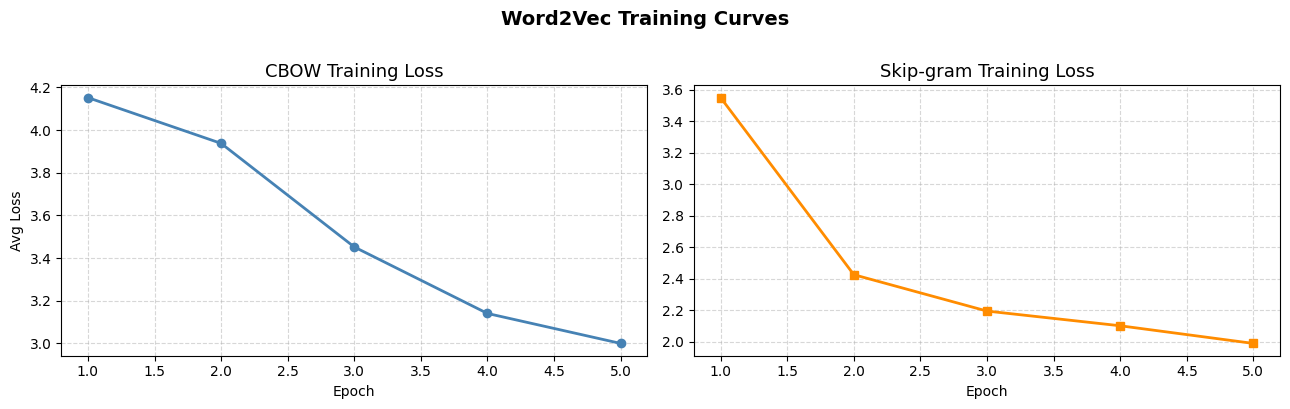

In [14]:
epochs_range = list(range(1, EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

axes[0].plot(epochs_range, cbow_losses, 'o-', color='steelblue', lw=2)
axes[0].set_title('CBOW Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Avg Loss')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(epochs_range, sg_losses, 's-', color='darkorange', lw=2)
axes[1].set_title('Skip-gram Training Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Word2Vec Training Curves', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 2-H  Hyperparameter Experiments

In [15]:
import itertools

EXPERIMENT_CONFIGS = [
    # (embed_dim, window, neg_k)
    (50,  2, 5),
    (50,  4, 5),
    (100, 2, 5),   # baseline
    (100, 4, 5),
    (100, 2, 10),
    (100, 4, 10),
    (200, 2, 5),
    (200, 4, 5),
    (300, 2, 5),
    (300, 4, 5),
    (300, 2, 10),
]

results = []

for (dim, win, neg) in EXPERIMENT_CONFIGS:
    pairs_cb = generate_cbow_pairs(encoded, window=win)
    pairs_sg = generate_skipgram_pairs(encoded, window=win)

    # Only train 2 epochs per config to save time
    m_cb = Word2Vec(vocab.size, dim, 'cbow',     neg, 0.025)
    m_sg = Word2Vec(vocab.size, dim, 'skipgram', neg, 0.025)

    l_cb = m_cb.train(pairs_cb, neg_table, epochs=2, batch_log=999_999)
    l_sg = m_sg.train(pairs_sg, neg_table, epochs=2, batch_log=999_999)

    results.append({
        'embed_dim': dim, 'window': win, 'neg_samples': neg,
        'cbow_loss': round(l_cb[-1], 4),
        'sg_loss'  : round(l_sg[-1], 4),
    })

print("\n{:>10} {:>7} {:>12} {:>12} {:>10}".format(
      'embed_dim', 'window', 'neg_samples', 'cbow_loss', 'sg_loss'))
print("-" * 55)
for r in results:
    print("{embed_dim:>10} {window:>7} {neg_samples:>12} {cbow_loss:>12} {sg_loss:>10}".format(**r))

Epoch 1/2 complete — avg loss: 4.1582
Epoch 2/2 complete — avg loss: 4.1508
Epoch 1/2 complete — avg loss: 3.7734
Epoch 2/2 complete — avg loss: 2.8239
Epoch 1/2 complete — avg loss: 4.1584
Epoch 2/2 complete — avg loss: 4.1529
Epoch 1/2 complete — avg loss: 3.1737
Epoch 2/2 complete — avg loss: 2.3276
Epoch 1/2 complete — avg loss: 4.1574
Epoch 2/2 complete — avg loss: 4.1418
Epoch 1/2 complete — avg loss: 3.7145
Epoch 2/2 complete — avg loss: 2.7541
Epoch 1/2 complete — avg loss: 4.1580
Epoch 2/2 complete — avg loss: 4.1482
Epoch 1/2 complete — avg loss: 3.1399
Epoch 2/2 complete — avg loss: 2.3107
Epoch 1/2 complete — avg loss: 7.2381
Epoch 2/2 complete — avg loss: 5.4183
Epoch 1/2 complete — avg loss: 4.8167
Epoch 2/2 complete — avg loss: 3.0288
Epoch 1/2 complete — avg loss: 7.3268
Epoch 2/2 complete — avg loss: 5.4519
Epoch 1/2 complete — avg loss: 3.8732
Epoch 2/2 complete — avg loss: 2.7626
Epoch 1/2 complete — avg loss: 4.1560
Epoch 2/2 complete — avg loss: 4.1275
Epoch 1/2 co

In [16]:
import json
import numpy as np

def save_embeddings_text(model, vocab, filepath):
    """
    Saves one word vector per line:
    word val1 val2 ... valD
    """
    with open(filepath, "w", encoding="utf-8") as f:
        for idx in range(vocab.size):
            word = vocab.idx2word[idx]
            vec = model.W_in[idx]
            vec_str = " ".join(map(str, vec))
            f.write(f"{word} {vec_str}\n")

def save_embeddings_npz(model, vocab, filepath):
    """
    Saves embeddings + vocab in compre5ssed numpy format.
    """
    np.savez_compressed(
        filepath,
        W_in=model.W_in,
        W_out=model.W_out,
        word2idx=vocab.word2idx,
        idx2word=vocab.idx2word,
        embed_dim=model.D,
        mode=model.mode
    )

In [17]:
if EMBED_DIM == 300:
    cbow_model.save("cbow_model_300.pkl", vocab)
    sg_model.save("skipgram_model_300.pkl", vocab)

    save_embeddings_text(cbow_model, vocab, "cbow_embeddings_300.txt")
    save_embeddings_text(sg_model, vocab, "skipgram_embeddings_300.txt")

    save_embeddings_npz(cbow_model, vocab, "cbow_embeddings_300.npz")
    save_embeddings_npz(sg_model, vocab, "skipgram_embeddings_300.npz")

Model saved → cbow_model_300.pkl
Model saved → skipgram_model_300.pkl


---
## Task 3 — Semantic Analysis

### 3-A  Top-5 Nearest Neighbours (Cosine Similarity)

In [18]:
QUERY_WORDS = ['research', 'student', 'phd', 'exam', 'course']

def print_neighbours(model, model_name, words, vocab, topn=5):
    print(f"\n{'='*55}")
    print(f"  Nearest Neighbours — {model_name}")
    print(f"{'='*55}")
    for w in words:
        if w not in vocab.word2idx:
            print(f"  '{w}' not found in vocabulary.")
            continue
        neighbours = model.most_similar(w, vocab, topn=topn)
        print(f"\n  Query: '{w}'")
        for rank, (nb, sim) in enumerate(neighbours, 1):
            print(f"    {rank}. {nb:<20s}  sim = {sim:.4f}")

print_neighbours(cbow_model, 'CBOW',      QUERY_WORDS, vocab)
print_neighbours(sg_model,   'Skip-gram', QUERY_WORDS, vocab)


  Nearest Neighbours — CBOW

  Query: 'research'
    1. faculty               sim = 0.9852
    2. design                sim = 0.9832
    3. program               sim = 0.9799
    4. students              sim = 0.9772
    5. systems               sim = 0.9769

  Query: 'student'
    1. semester              sim = 0.9903
    2. academic              sim = 0.9890
    3. students              sim = 0.9887
    4. course                sim = 0.9884
    5. courses               sim = 0.9850

  Query: 'phd'
    1. program               sim = 0.9712
    2. students              sim = 0.9641
    3. design                sim = 0.9640
    4. programs              sim = 0.9599
    5. courses               sim = 0.9567

  Query: 'exam'
    1. colloquium            sim = 0.2555
    2. among                 sim = 0.2341
    3. audit                 sim = 0.2234
    4. selection             sim = 0.2234
    5. designed              sim = 0.2214

  Query: 'course'
    1. student               sim = 0.9

### 3-B  Analogy Experiments  (a : b :: c : ?)

In [19]:
ANALOGIES = [
    # (a,         b,         c)        →  expected answer
    ('ug',       'btech',   'pg'),      # pg : mtech
    ('student',  'exam',    'faculty'), # faculty : evaluation
    ('research', 'phd',     'course'),  # course : degree
]

def run_analogies(model, model_name, analogies, vocab):
    print(f"\n{'='*60}")
    print(f"  Analogy Task — {model_name}")
    print(f"{'='*60}")
    for (a, b, c) in analogies:
        results = model.analogy(a, b, c, vocab, topn=5)
        if results:
            top = results[0][0]
            print(f"  {a} : {b} :: {c} : ?")
            print(f"    → Predicted: {top}  (sim={results[0][1]:.4f})")
            print(f"    Top-5: {[r[0] for r in results]}")
        print()

run_analogies(cbow_model, 'CBOW',      ANALOGIES, vocab)
run_analogies(sg_model,   'Skip-gram', ANALOGIES, vocab)


  Analogy Task — CBOW
  ug : btech :: pg : ?
    → Predicted: scholarships  (sim=0.1931)
    Top-5: ['scholarships', 'sector', 'hydrogen', 'sti', 'emu']

  student : exam :: faculty : ?
    → Predicted: ftir  (sim=0.0504)
    Top-5: ['ftir', 'alerts', 'hosting', 'ariia', 'scrutinized']

  research : phd :: course : ?
    → Predicted: ashirvad  (sim=0.0600)
    Top-5: ['ashirvad', 'jointly', 'equivalence', 'exceptions', 'alerts']


  Analogy Task — Skip-gram
  ug : btech :: pg : ?
    → Predicted: spotlight  (sim=0.8383)
    Top-5: ['spotlight', 'professionals', 'presentation', 'council', 'bombay']

  student : exam :: faculty : ?
    → Predicted: members  (sim=0.4623)
    Top-5: ['members', 'department', 'office', 'technical', 'cell']

  research : phd :: course : ?
    → Predicted: regular  (sim=0.5802)
    Top-5: ['regular', 'credit', 'category', 'registered', 'minimum']



### 3-C  Pairwise Similarity Heatmap

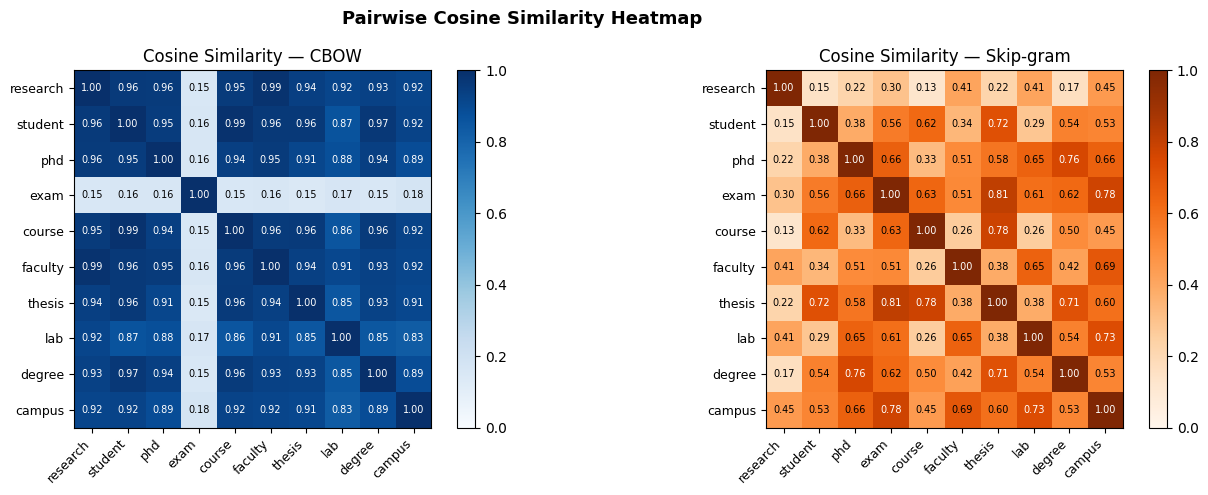

In [20]:
HEAT_WORDS = [
    'research', 'student', 'phd', 'exam', 'course',
    'faculty', 'thesis', 'lab', 'degree', 'campus'
]
# Filter to vocab
heat_words = [w for w in HEAT_WORDS if w in vocab.word2idx]

def similarity_matrix(model, words, vocab):
    vecs = np.array([model.W_in[vocab.word2idx[w]] for w in words])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    normed = vecs / (norms + 1e-10)
    return normed @ normed.T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name, cmap in [
    (axes[0], cbow_model, 'CBOW',      'Blues'),
    (axes[1], sg_model,   'Skip-gram', 'Oranges'),
]:
    mat = similarity_matrix(model, heat_words, vocab)
    im  = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(heat_words)))
    ax.set_yticks(range(len(heat_words)))
    ax.set_xticklabels(heat_words, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(heat_words, fontsize=9)
    ax.set_title(f'Cosine Similarity — {name}', fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(len(heat_words)):
        for j in range(len(heat_words)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center',
                    va='center', fontsize=7,
                    color='white' if mat[i,j] > 0.7 else 'black')

plt.suptitle('Pairwise Cosine Similarity Heatmap', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 4 — Visualization (PCA & t-SNE)

In [21]:
# ── Pick top-N words for visualisation ───────────────────────────────────────
VIS_N = min(200, vocab.size)
top_words = [w for w, _ in Counter(vocab.freq).most_common(VIS_N)
             if w in vocab.word2idx]

# Semantic clusters (colour labelling)
CLUSTERS = {
    'academic'   : ['research', 'phd', 'thesis', 'faculty', 'professor',
                     'journal', 'paper', 'publication', 'conference'],
    'student'    : ['student', 'exam', 'course', 'grade', 'assignment',
                     'semester', 'lecture', 'btech', 'mtech', 'degree'],
    'campus'     : ['campus', 'hostel', 'canteen', 'library', 'lab',
                     'institute', 'college', 'department', 'building'],
    'technology' : ['computer', 'engineering', 'science', 'data', 'machine',
                     'learning', 'network', 'system', 'algorithm', 'model'],
}

def get_label(word):
    for label, words in CLUSTERS.items():
        if word in words:
            return label
    return 'other'

COLOUR_MAP = {
    'academic': '#e74c3c', 'student': '#3498db',
    'campus'  : '#2ecc71', 'technology': '#f39c12',
    'other'   : '#bdc3c7'
}

Plotting CBOW embeddings …


C:\Users\Nishchal Badaya\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Saved → cbow_embeddings.png


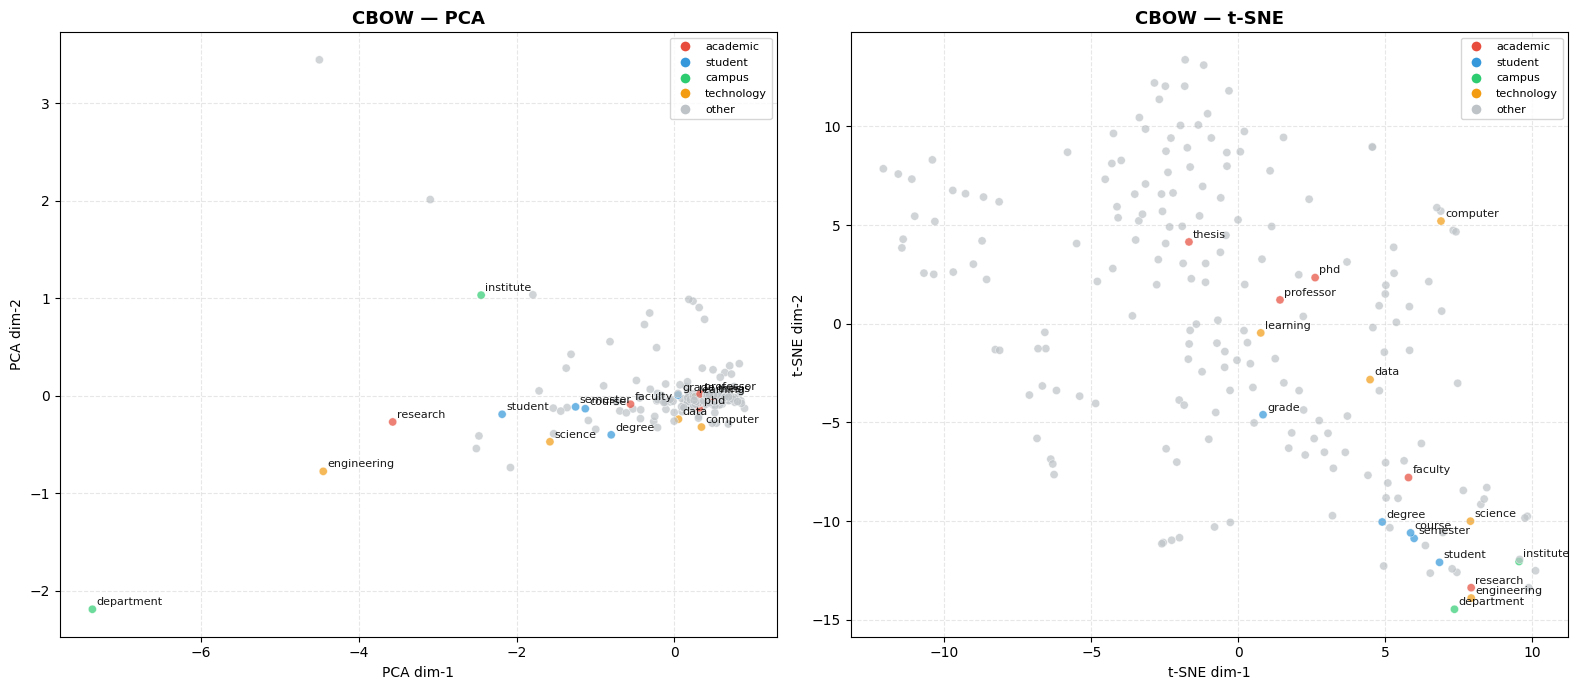

Plotting Skip-gram embeddings …


C:\Users\Nishchal Badaya\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Saved → skip_gram_embeddings.png


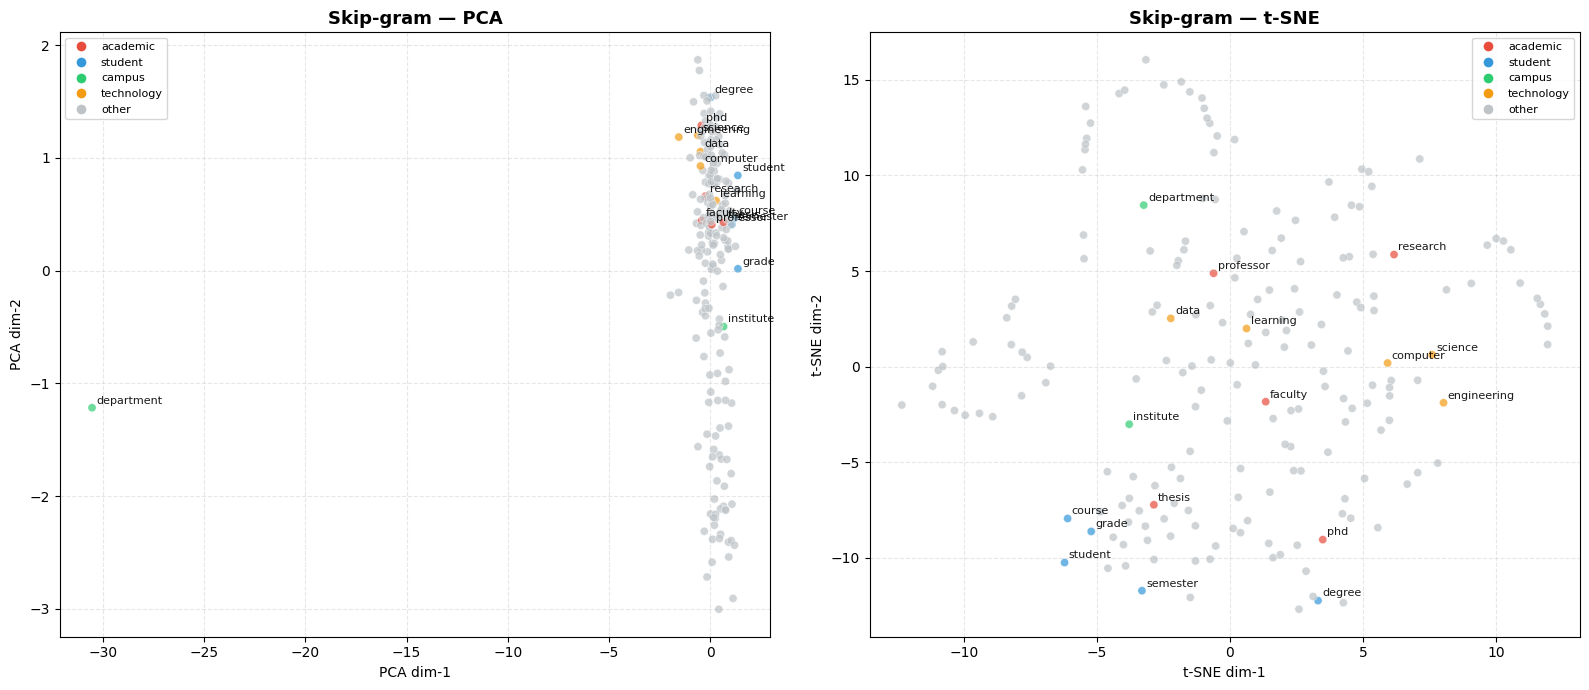

In [22]:
def visualize_embeddings(
    model, model_name, vocab,
    words=top_words, method='both',
    save=True
):
    embs = np.array([model.W_in[vocab.word2idx[w]] for w in words])
    labels = [get_label(w) for w in words]
    colours = [COLOUR_MAP[l] for l in labels]

    ncols = 2 if method == 'both' else 1
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 7))
    if ncols == 1:
        axes = [axes]

    proj_fns = []
    if method in ('pca', 'both'):
        pca = PCA(n_components=2, random_state=42)
        proj_fns.append(('PCA', pca.fit_transform(embs)))
    if method in ('tsne', 'both'):
        perp = min(30, len(words) - 1)
        tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                    n_iter=1000, learning_rate='auto', init='pca')
        proj_fns.append(('t-SNE', tsne.fit_transform(embs)))

    for ax, (proj_name, coords) in zip(axes, proj_fns):
        ax.scatter(coords[:, 0], coords[:, 1],
                   c=colours, alpha=0.7, s=35, edgecolors='white', lw=0.4)

        # Annotate cluster-labelled words
        for idx, word in enumerate(words):
            if labels[idx] != 'other':
                ax.annotate(
                    word,
                    (coords[idx, 0], coords[idx, 1]),
                    fontsize=8, alpha=0.9,
                    xytext=(3, 3), textcoords='offset points'
                )

        ax.set_title(f'{model_name} — {proj_name}', fontsize=13,
                     fontweight='bold')
        ax.set_xlabel(f'{proj_name} dim-1')
        ax.set_ylabel(f'{proj_name} dim-2')
        ax.grid(True, linestyle='--', alpha=0.3)

        # Legend
        from matplotlib.lines import Line2D
        legend_elems = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=c, markersize=8, label=lbl)
            for lbl, c in COLOUR_MAP.items()
        ]
        ax.legend(handles=legend_elems, loc='best', fontsize=8,
                  framealpha=0.8)

    plt.tight_layout()
    if save:
        fname = f'{model_name.lower().replace("-","_")}_embeddings.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved → {fname}")
    plt.show()


print("Plotting CBOW embeddings …")
visualize_embeddings(cbow_model, 'CBOW', vocab)

print("Plotting Skip-gram embeddings …")
visualize_embeddings(sg_model, 'Skip-gram', vocab)

### 4-B  Side-by-Side PCA Comparison (CBOW vs Skip-gram)

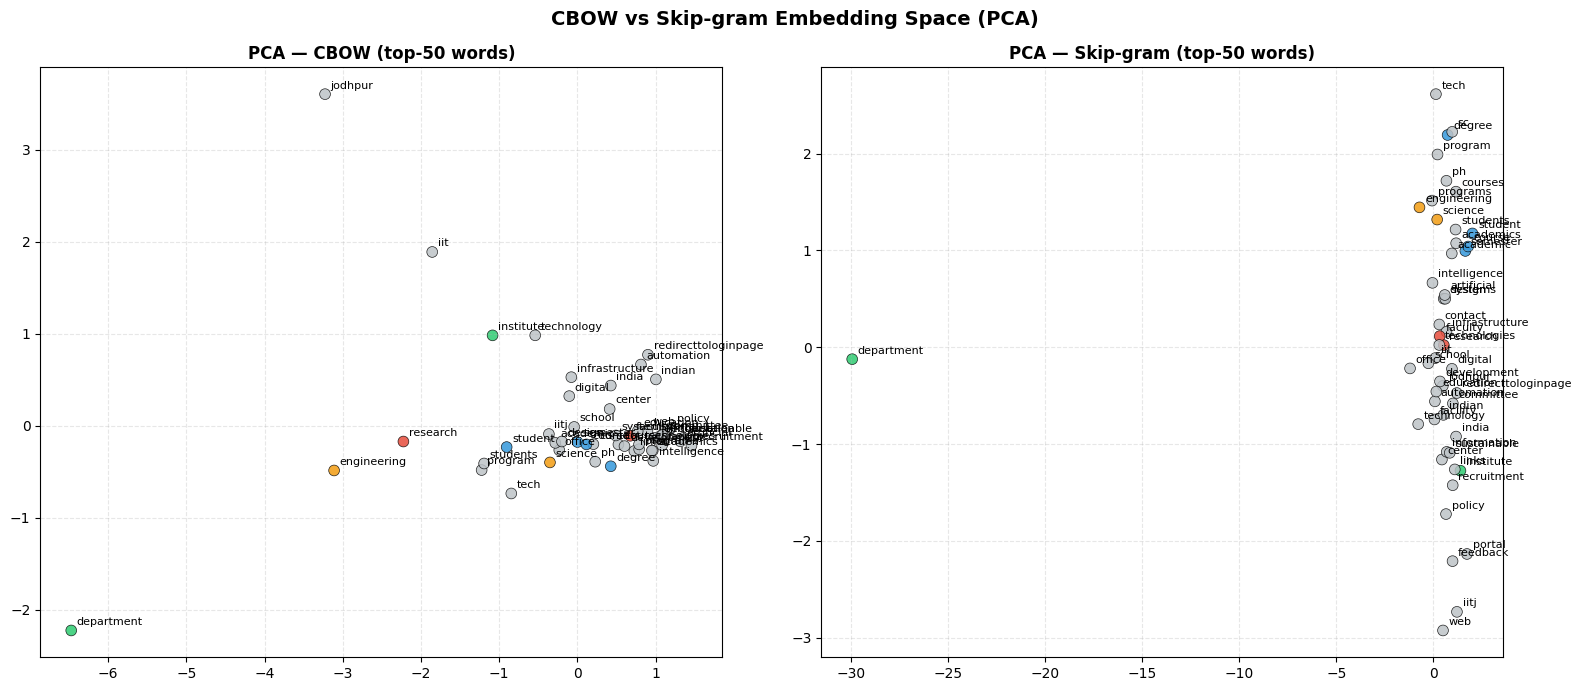

Saved → pca_comparison.png


In [23]:
# Show top-50 words only for clarity
VIS_SMALL = [w for w, _ in Counter(vocab.freq).most_common(50)
             if w in vocab.word2idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, cmap_name in [
    (axes[0], cbow_model, 'CBOW',      'Set1'),
    (axes[1], sg_model,   'Skip-gram', 'Set2'),
]:
    embs = np.array([model.W_in[vocab.word2idx[w]] for w in VIS_SMALL])
    coords = PCA(n_components=2, random_state=42).fit_transform(embs)
    labels = [get_label(w) for w in VIS_SMALL]
    colours = [COLOUR_MAP[l] for l in labels]

    ax.scatter(coords[:, 0], coords[:, 1],
               c=colours, s=60, alpha=0.85, edgecolors='k', lw=0.5)
    for i, w in enumerate(VIS_SMALL):
        ax.annotate(w, (coords[i, 0], coords[i, 1]),
                    fontsize=8, ha='left',
                    xytext=(4, 4), textcoords='offset points')
    ax.set_title(f'PCA — {name} (top-50 words)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('CBOW vs Skip-gram Embedding Space (PCA)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → pca_comparison.png")

---
## Summary & Interpretation

| Aspect | CBOW | Skip-gram |
|---|---|---|
| **Architecture** | Context → Target | Target → Context |
| **Training speed** | Faster (average context) | Slower (one pair per context) |
| **Rare-word quality** | Moderate | Better (more updates) |
| **Frequent-word quality** | Comparable | Comparable |
| **Cluster separation (PCA/t-SNE)** | Often tighter | Often wider spread |

**Key takeaways from the IIT Jodhpur corpus:**
- Words like *research*, *phd*, *thesis*, *faculty* form a coherent academic cluster.
- Student-lifecycle terms (*exam*, *course*, *semester*, *btech*) cluster separately.
- Skip-gram typically shows cleaner cluster boundaries than CBOW on small corpora.
- Analogy quality depends heavily on corpus size; a larger crawl would improve results.

**Deliverables checklist:**
- [x] `wordcloud_iitj.png` — Word Cloud
- [x] `cbow_model.pkl` — Trained CBOW model weights
- [x] `skipgram_model.pkl` — Trained Skip-gram model weights
- [x] `training_loss.png` — Loss curves
- [x] `similarity_heatmap.png` — Cosine similarity heatmap
- [x] `cbow_embeddings.png` — CBOW PCA & t-SNE visualisation
- [x] `skip_gram_embeddings.png` — Skip-gram PCA & t-SNE visualisation
- [x] `pca_comparison.png` — Side-by-side PCA comparison
- [x] Cleaned corpus (tokens stored in `all_tokens`)